# Separate and Entangled States

## 1. Displaying possible states for two-qubit system
For theoretical take and full explanation; reader can check [entanglement](https://learnquantum.io/chapters/02_quantum_computing/02_02_entanglement.html) in [Learn Quantum Computing using Python](https://learnquantum.io/index.html) by Diego Emilio Serrano. Here, only the code part for the creation of quantum circuit of resulting Bell states will be given for quick usage in the feature.

### 1.1 Two-qubit circuits for separable states:

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_sep = QuantumCircuit(2)    # define quantum circuit
qc_sep.h(1)                   # apply H gate to qubit 1
qc_sep.x(0)                   # apply X gate to qubit 0
qc_sep.h(0)                   # apply H gate to qubit 0

display(qc_sep.draw())        # draw circuit
display(Statevector(qc_sep))  # display statevector
print("Final Statevector in latex form:")
display(Statevector(qc_sep).draw('latex'))  # display statevector

┌───┐┌───┐
q_0: ┤ X ├┤ H ├
     ├───┤└───┘
q_1: ┤ H ├─────
     └───┘

Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))
Final Statevector in latex form:


<IPython.core.display.Latex object>

In [2]:
# Add measurement blocks
qc_sep.measure_all()
display(qc_sep.draw())

┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ X ├┤ H ├─░─┤M├───
        ├───┤└───┘ ░ └╥┘┌─┐
   q_1: ┤ H ├──────░──╫─┤M├
        └───┘      ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

Performing circuit simulation for separable states

In [3]:
# perform circuit simulation
from qiskit.providers.basic_provider import BasicSimulator

simulator = BasicSimulator()             # define simulator object
job = simulator.run(qc_sep, shots=1000)  # use run method to execute our circuit some number of shots
result = job.result()                    # extract our results
counts = result.get_counts()             # get the counts from the experiment

print(counts)

{'01': 265, '00': 245, '10': 239, '11': 251}


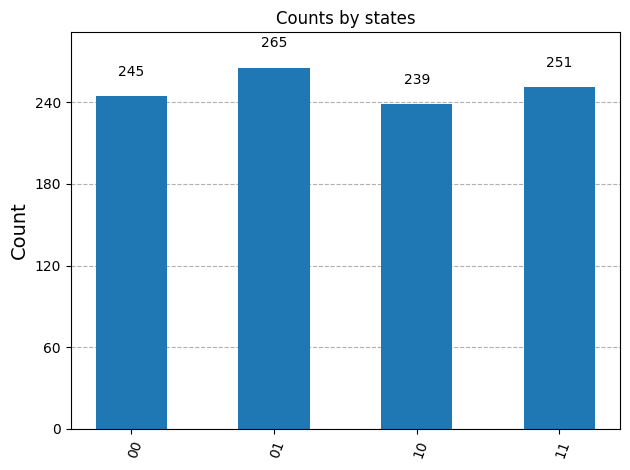

In [4]:
from qiskit.visualization import plot_histogram
plot_histogram(counts, title='Counts by states')

### 1.2 Two-qubit circuit for entangled states:

In [5]:
# Define state: 00 of the system via Statevector
q = Statevector.from_label('00')
q.draw('latex', convention='vector', prefix=r'|q\rangle = ')

<IPython.core.display.Latex object>

Define operations $ H, I, H \otimes I$ for obtaining entangled states:

In [6]:
from qiskit.quantum_info import Operator

# Define operations for obtaining entangled states

# Define H
H = Operator.from_label('H')
display(H.draw('latex', prefix = 'H = '))

# Define I
I = Operator.from_label('I')
display(I.draw('latex', prefix = 'I = '))

# Compose H⊗I
HI = H.tensor(I)
display(HI.draw('latex', prefix = r'H \otimes I = '))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Apply $H \otimes I $ on $\ket{00}$:

In [7]:
q = q.evolve(HI)
q.draw('latex', convention='vector', prefix=r'|q\rangle = ')

<IPython.core.display.Latex object>

Define $CX$ (CNOT) operation:

In [8]:
CX = Operator([[1,0,0,0],
               [0,1,0,0],
               [0,0,0,1],
               [0,0,1,0]])
display(CX.draw('latex', prefix = 'CX = '))

<IPython.core.display.Latex object>

Apply $CX$ opetration on the circuit:

In [9]:
q = q.evolve(CX)
display(q.draw('latex', convention='vector', prefix=r'|q\rangle = '))
display(q.draw('latex', prefix=r'|q\rangle = '))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Similarly obtaining same result via Qiskit quantum circuit:

In [10]:
qc_ent = QuantumCircuit(2)    # define quantum circuit
qc_ent.h(1)                   # apply H gate to qubit 1
qc_ent.cx(1,0)                # apply CX with control on q1 and target on q0

display(qc_ent.draw())        # draw circuit
display(Statevector(qc_ent))  # display statevector
print("Final state latex form: ")
display(Statevector(qc_ent).draw('latex'))  # display statevector in latex form

┌───┐
q_0: ─────┤ X ├
     ┌───┐└─┬─┘
q_1: ┤ H ├──■──
     └───┘

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Final state latex form: 


<IPython.core.display.Latex object>

Measurements on the circuit:

In [11]:
# Add measurement blocks
qc_ent.measure_all()
display(qc_ent.draw())

┌───┐ ░ ┌─┐   
   q_0: ─────┤ X ├─░─┤M├───
        ┌───┐└─┬─┘ ░ └╥┘┌─┐
   q_1: ┤ H ├──■───░──╫─┤M├
        └───┘      ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

Performing circuit simulation for entangled states:

In [12]:
# perform circuit simulation
job = simulator.run(qc_ent, shots=1000)  # use run method to execute our circuit some number of shots
result = job.result()                    # extract our results
counts = result.get_counts()             # get the counts from the experiment

print(counts)

{'11': 506, '00': 494}


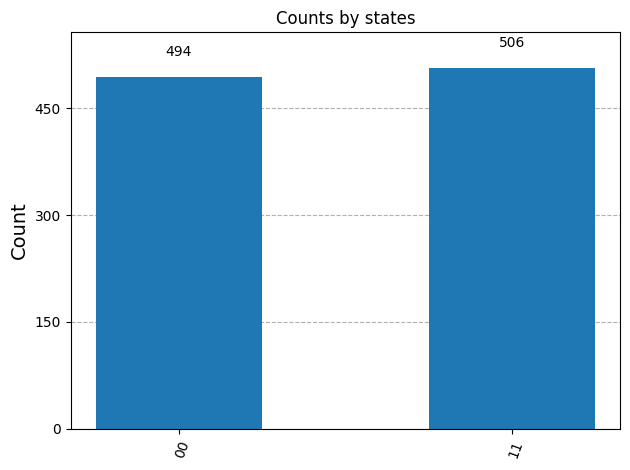

In [13]:
plot_histogram(counts, title='Counts by states')

In [28]:
qc_ghz_ent = QuantumCircuit(3)    # define quantum circuit of 3-qubit
qc_ghz_ent.h(0)                   # apply H gate to qubit 1
qc_ghz_ent.cx(0,1)                # apply CX with control on q0 and target on q1
qc_ghz_ent.cx(0,2)                # apply CX with control on q0 and target on q2

display(qc_ghz_ent.draw())        # draw circuit
display(Statevector(qc_ghz_ent))  # display statevector
print("Final state latex form: ")
display(Statevector(qc_ghz_ent).draw('latex'))  # display statevector in latex form

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))
Final state latex form: 


<IPython.core.display.Latex object>

In [29]:
# Add measurement blocks
qc_ghz_ent.measure_all()
display(qc_ghz_ent.draw())

┌───┐           ░ ┌─┐      
   q_0: ┤ H ├──■────■───░─┤M├──────
        └───┘┌─┴─┐  │   ░ └╥┘┌─┐   
   q_1: ─────┤ X ├──┼───░──╫─┤M├───
             └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ──────────┤ X ├─░──╫──╫─┤M├
                  └───┘ ░  ║  ║ └╥┘
meas: 3/═══════════════════╩══╩══╩═
                           0  1  2

In [30]:
# perform circuit simulation
job = simulator.run(qc_ghz_ent, shots=1000)  # use run method to execute our circuit some number of shots
result = job.result()                    # extract our results
counts = result.get_counts()             # get the counts from the experiment

print(counts)

{'000': 497, '111': 503}


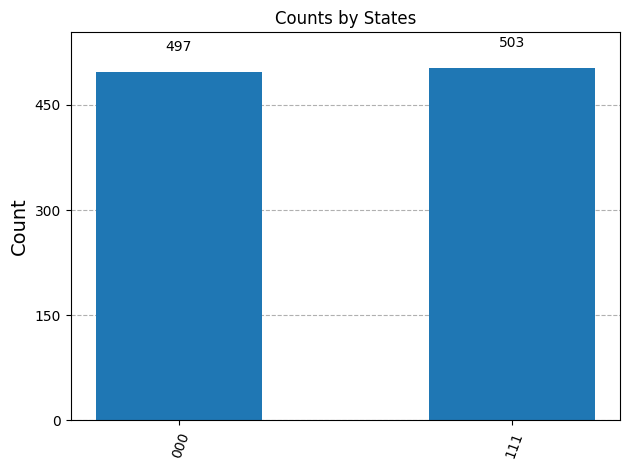

In [31]:
plot_histogram(counts, title='Counts by States')